In [7]:
from raw_data_analysis.utils import get_daily_calls_global, train_test_split
import warnings
warnings.filterwarnings('ignore')
daily_calls = get_daily_calls_global(weather=True, total=True, events=True, root_path='raw_data_analysis')

In [8]:
daily_calls.head()

,received_date,calls,dayofweek,month,year,week,season,lag1,lag2,lag3,...,lag6,lag7,lag14,lag21,tempmax,cloudcover,giants_game,new_years,pride,thanksgiving
0,2004-10-19,195,1,10,2004,43,3,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,none,0.0,0.0,0.0
1,2004-10-20,207,2,10,2004,43,3,195.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,none,0.0,0.0,0.0
2,2004-10-21,187,3,10,2004,43,3,207.0,195.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,none,0.0,0.0,0.0
3,2004-10-22,197,4,10,2004,43,3,187.0,207.0,195.0,...,NaN,NaN,NaN,NaN,NaN,NaN,none,0.0,0.0,0.0
4,2004-10-23,181,5,10,2004,43,3,197.0,187.0,207.0,...,NaN,NaN,NaN,NaN,NaN,NaN,none,0.0,0.0,0.0


In [9]:
daily_calls.loc[:, 'call_diff'] = daily_calls.calls.diff()
daily_calls.loc[:, 'call_diff_pos'] = daily_calls.call_diff > 0
daily_calls.loc[:, 'difflag1'] = daily_calls.call_diff.shift(1)
daily_calls.loc[:, 'difflag2'] = daily_calls.call_diff.shift(2)
daily_calls.loc[:, 'difflag3'] = daily_calls.call_diff.shift(3)
daily_calls.loc[:, 'difflag4'] = daily_calls.call_diff.shift(4)
daily_calls.loc[:, 'difflag5'] = daily_calls.call_diff.shift(5)
daily_calls.loc[:, 'difflag6'] = daily_calls.call_diff.shift(6)
daily_calls.loc[:, 'difflag7'] = daily_calls.call_diff.shift(7)
daily_calls.loc[:, 'difflag14'] = daily_calls.call_diff.shift(14)
train, valid, _ = train_test_split(daily_calls.iloc[439:], n_valid=365)

In [10]:
daily_calls.groupby('dayofweek').call_diff_pos.mean()

dayofweek
0    0.468451
1    0.447519
2    0.528736
3    0.541031
4    0.658677
5    0.462417
6    0.384321
Name: call_diff_pos, dtype: float64

In [11]:
from sklearn import metrics
from dataclasses import dataclass
import matplotlib.pyplot as plt
import pandas as pd

@dataclass
class PlotArgs:
   fig_i: int
   model: str
def validation_metrics(y_true, y_pred):
  assert len(y_true) == len(y_pred)
  yidx = list(range(len(y_true)))

  print(f'RMSE: {metrics.root_mean_squared_error(y_true, y_pred):.4}')
  print(f'MAPE: {metrics.mean_absolute_percentage_error(y_true, y_pred):.4f}')
  print(f'MAE: {metrics.mean_absolute_error(y_true, y_pred):.4f}')
  plt.plot(yidx, y_true, label='True')
  plt.plot(yidx, y_pred, label='Predicted')
  plt.legend()

#   validation_months = pd.date_range(start="2023-11-01", end="2024-10-01", freq="MS")
#   month_tick_pos = valid[valid.received_date.isin(validation_months)].index-valid.index[0]
#   plt.xticks(
#      ticks=list(month_tick_pos),
#      labels=['Nov 01, 23', 'Dec 01', 'Jan 01, 24', 'Feb 01', 'Mar 01', 'Apr 01',
#              'May 01', 'Jun 01', 'Jul 01', 'Aug 01', 'Sep 01', 'Oct 01'],
#      rotation=40
#      )

def eval_lasso(model, X_valid, y_valid, transformer):
    reg = model.named_steps['lassocv']
    feats_coefs = pd.DataFrame({
        'feature': transformer.get_feature_names_out(),
        'coefficient': reg.coef_})
    print('Top 15 features:')
    print(feats_coefs.sort_values('coefficient', key=abs, ascending=False).head(15))
    print(f'Used {(reg.coef_ != 0).sum()}/{len(reg.coef_)} features')
    validation_metrics(y_valid, model.predict(X_valid))

In [12]:
def plot_resids(model, X, y):
  plt.scatter(y, model.predict(X) - y)

<Axes: xlabel='dayofweek', ylabel='call_diff'>

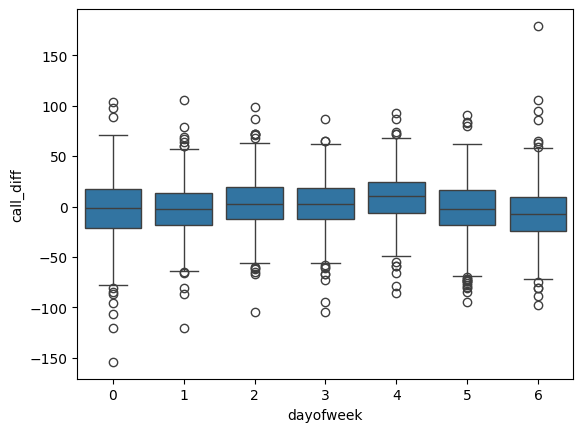

In [13]:
import seaborn as sns
sns.boxplot(train, x='dayofweek', y='call_diff')

<Axes: xlabel='week'>

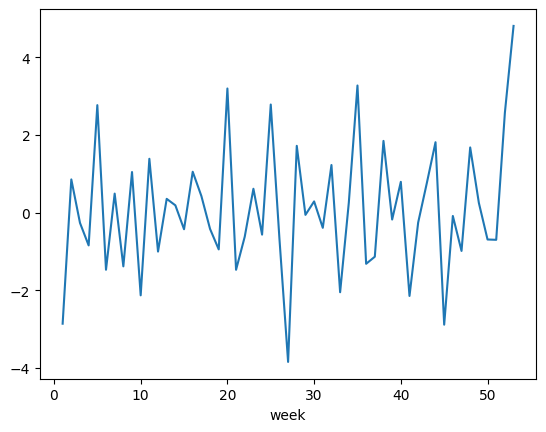

In [14]:
train.groupby('week').call_diff.mean().plot()

<Axes: xlabel='month'>

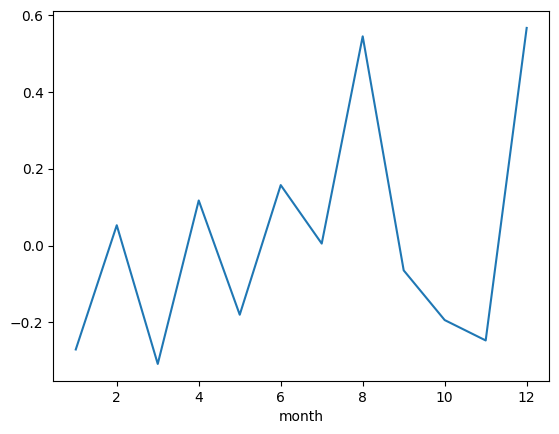

In [15]:
train.groupby('month').call_diff.mean().plot()

Top 15 features:
                feature  coefficient
0      scaler__difflag1  -123.279018
8  encoder__dayofweek_6    -8.400968
6  encoder__dayofweek_4     8.042780
2  encoder__dayofweek_0    -5.604342
3  encoder__dayofweek_1    -4.188442
1      scaler__difflag7     3.811482
5  encoder__dayofweek_3     1.955501
4  encoder__dayofweek_2     0.552297
7  encoder__dayofweek_5     0.000000
Used 8/9 features
RMSE: 25.75
MAPE: 239362095087721.5625
MAE: 20.3438


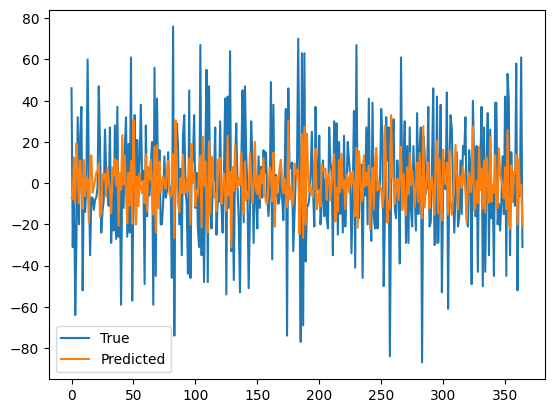

In [18]:
from sklearn.linear_model import LassoCV
from sklearn.pipeline import make_pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler
from sklearn.model_selection import TimeSeriesSplit

num_cols = ['difflag1', 'difflag7']
cat_cols = ['dayofweek']

feats = num_cols + cat_cols
X_train, y_train = train[feats], train.call_diff
X_valid, y_valid = valid[feats], valid.call_diff

# This will create 5 splits in our training data during cross fold validation
# that we'll use for the rest of this analysis.
# |-------------------original training data------------------------|
# |--------------train1--------------|-val1-|
# |--------------train2---------------------|-val2-|
# |--------------train3----------------------------|-val3-|
# |--------------train4-----------------------------------|val4|
# |--------------train5----------------------------------------|val5|
ts_cv = TimeSeriesSplit(
    n_splits=5,
    test_size=365,
)

transformer = ColumnTransformer([
        ('scaler', MinMaxScaler(), num_cols),
        ('encoder', OneHotEncoder(), cat_cols)
    ], remainder='passthrough')

model = make_pipeline(transformer, LassoCV(random_state=0, cv=ts_cv))
model.fit(X_train, y_train)
eval_lasso(model, X_valid, y_valid, transformer)
reg = model.named_steps['lassocv']
feats = transformer.get_feature_names_out()
used_feats = feats[reg.coef_ != 0]

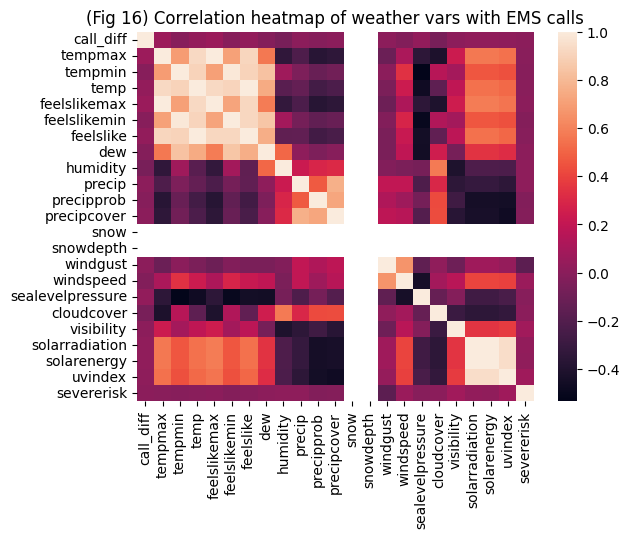

In [20]:
import pandas as pd
weather = pd.concat([
  pd.read_csv("raw_data_analysis/sf-daily-20140101-20241021.csv"),
  pd.read_csv("raw_data_analysis/sf-daily-20060101-20131231.csv")])
weather.datetime = pd.to_datetime(weather.datetime)
weather.severerisk = weather.severerisk.fillna(0)
train_weather = pd.merge(train.drop(['tempmax', 'cloudcover'], axis=1), weather, left_on='received_date', right_on='datetime', how='left')

num_weather_feats = [
    'tempmax', 'tempmin', 'temp', 'feelslikemax',
    'feelslikemin', 'feelslike', 'dew', 'humidity', 'precip', 'precipprob',
    'precipcover', 'snow', 'snowdepth', 'windgust',
    'windspeed', 'sealevelpressure', 'cloudcover', 'visibility',
    'solarradiation', 'solarenergy', 'uvindex', 'severerisk'
]
corr = train_weather[['call_diff'] + num_weather_feats].corr()
fig, ax = plt.subplots()
sns.heatmap(corr, ax=ax)
ax.set_title('(Fig 16) Correlation heatmap of weather vars with EMS calls');

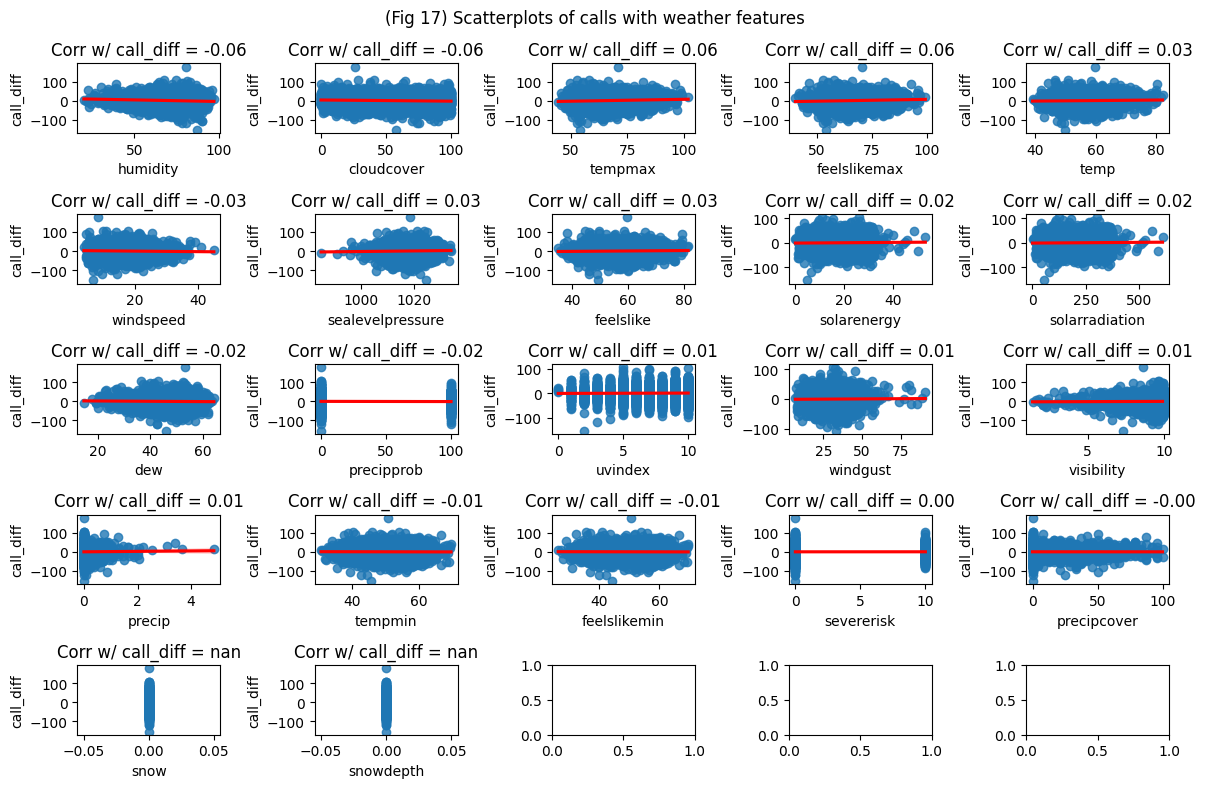

In [21]:
fig, axs = plt.subplots(5, 5, figsize=(12,8))
sorted_weather_feats = list(corr.call_diff.abs().sort_values(ascending=False).index)[1:]
for i in range(len(sorted_weather_feats)):
    weather_feat = sorted_weather_feats[i]
    sns.regplot(train_weather, x=weather_feat, y='call_diff', ax=axs[i//5][i%5],
                line_kws=dict(color="r"))
    axs[i//5][i%5].set_title(f'Corr w/ call_diff = {corr.call_diff[weather_feat]:.2f}')
plt.suptitle('(Fig 17) Scatterplots of calls with weather features');
plt.tight_layout()

In [22]:
giants_games = pd.read_csv('raw_data_analysis/giants_games.csv')
warriors_games = pd.read_csv('raw_data_analysis/warriors_games.csv')
niners_games = pd.read_csv('raw_data_analysis/niners_games.csv')
giants_games.date = pd.to_datetime(giants_games.date)
warriors_games.date = pd.to_datetime(warriors_games.date)
niners_games.date = pd.to_datetime(niners_games.date)
train_events = pd.merge(train_weather, warriors_games, left_on='received_date', right_on='date', how='left')\
    .rename(columns={'home_game': 'warriors_home_game', 'playoff_game': 'warriors_playoff_game'})\
    .drop(labels=['date'], axis=1)
train_events = pd.merge(train_events, giants_games, left_on='received_date', right_on='date', how='left')\
    .rename(columns={'home_game': 'giants_home_game'})\
    .drop(labels=['date'], axis=1)
train_events = pd.merge(train_events, niners_games, left_on='received_date', right_on='date', how='left')\
    .rename(columns={'home_game': 'niners_home_game'})\
    .drop(labels=['date'], axis=1)
train_events.warriors_home_game = train_events.warriors_home_game.fillna(-1)
train_events.warriors_playoff_game = train_events.warriors_playoff_game.fillna(-1)
train_events.giants_home_game = train_events.giants_home_game.fillna(-1)
train_events.niners_home_game = train_events.niners_home_game.fillna(-1)

special_events = pd.read_csv('raw_data_analysis/special-events.csv')
special_events.date = pd.to_datetime(special_events.date)
# make sure all events are on unique days before merging
assert special_events.shape[0] == special_events.date.nunique()
train_events = pd.merge(train_events, special_events, left_on='received_date', right_on='date', how='left')\
    .drop(labels=['date'], axis=1).rename(columns={'name_y': 'event'})
train_events.event = train_events.event.fillna('None')


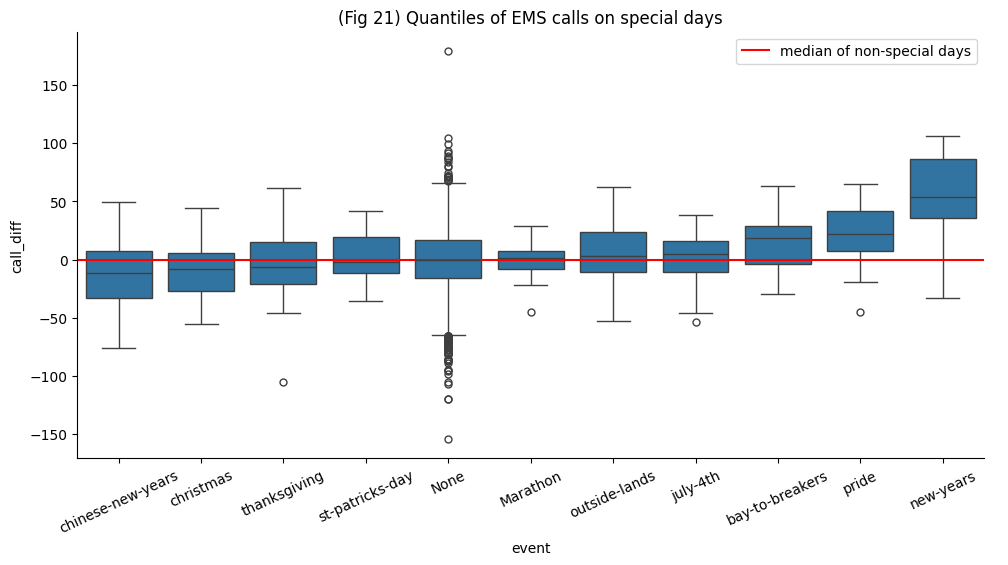

In [24]:
event_calls = train_events.groupby('event').call_diff.median().sort_values()
sns.catplot(train_events, y="call_diff", x="event", kind="box", order=event_calls.index,
            legend_out=True, aspect=2)
plt.axhline(y=event_calls['None'], color='r', label='median of non-special days')
plt.xticks(rotation=25)
plt.legend()
plt.title('(Fig 21) Quantiles of EMS calls on special days');